# Exploratory Data Analysis

<div style="text-align: justify">

The following notebook is dedicated to exploratory data analysis for the <b>Tau Supersymmetry</b> search analysis. EDA is performed on the rectangularized MC DataFrame produced by the feature engineering pipeline, and covers data quality, class balance, feature correlations, and feature distributions.

</div>

## Analysis Steps

| Step | Module | Description |
|------|--------|-------------|
| Config | `hydra.compose` | Load analysis configuration |
| Load | `io.load_dataframe` | Read mc.parquet from feature engineering output |
| Labels | — | Derive class names from eventOrigin |
| Missing | `eda.checks.summarize_missing` | Check for remaining NaN values |
| Ranges | `eda.checks.summarize_feature_ranges` | Per-class min, max, mean and std per feature |
| Balance | `eda.plots.plot_class_balance` | Event counts before and after class weighting |
| Correlation | `eda.plots.plot_correlation_matrix` | Pearson feature correlation heatmap |
| Distributions | `eda.plots.plot_feature_distributions` | Per-class normalized feature histograms |

The same analysis is available as a CLI via `python eda.py` or `make eda`.

## Initialization

### Libraries

Configuration:
* [Hydra](https://hydra.cc/)
* [OmegaConf](https://omegaconf.readthedocs.io/)
* [pyrootutils](https://github.com/ashleve/pyrootutils)

Data Processing:
* [Pandas](https://pandas.pydata.org/)

Data Visualization:
* [Matplotlib](https://matplotlib.org/)
* [Seaborn](https://seaborn.pydata.org/)

Serialization:
* [Apache Parquet](https://parquet.apache.org/)

### Notebook

Activating autoreload of imported modules.

In [1]:
%load_ext autoreload
%autoreload 2

Initializing the project root.

In [2]:
import pyrootutils

path = pyrootutils.setup_root(
    search_from=__file__ if "__file__" in locals() else ".",
    indicator=".gitignore",
    pythonpath=True,
)

Suppressing unessential warnings and applying ATLAS style.

In [3]:
from src.utils import suppress_warnings
from src.visualization.plots import apply_atlas_style

suppress_warnings()
apply_atlas_style()

Unessential warnings suppressed.
ATLAS style applied with LaTeX.


## Configuration

Loading the Hydra configuration. All analysis parameters (run, region, channel, samples, features) are defined in `configs/` and can be overridden here.

In [4]:
from hydra import compose, initialize_config_dir

initialize_config_dir(config_dir=str(path / "configs"), version_base="1.3")
cfg = compose(config_name="config")

Resolving the input and output directories from config.

In [5]:
from src.processing.analysis import get_output_paths

output_paths = get_output_paths(cfg)
dataframes_dir = path / output_paths["dataframes_dir"]
plots_dir = path / output_paths["plots_dir"] / "eda"
plots_dir.mkdir(parents=True, exist_ok=True)

## Deserialization

Loading the MC DataFrame produced by the feature engineering pipeline.

In [6]:
from src.processing.io import load_dataframe

df_mc = load_dataframe(dataframes_dir / "mc.parquet")

## Class Labels

Deriving ordered class names from `eventOrigin` for use in plots and tables.

In [7]:
from src.eda.utils import get_class_names

class_names = get_class_names(df_mc)
class_names

['topquarks', 'wtaunu', 'ztautau', 'diboson', 'other', 'signal']

In [8]:
df_mc

,nVtx,LeptonVeto,jet_n,jet_n_btag,sumMTJet,sumMTTauJet,met,met_phi,METSig,meff,...,jet_jvt_2,jet_delPhiMet_0,jet_delPhiMet_1,jet_delPhiMet_2,jet_width_0,jet_width_1,jet_width_2,eventOrigin,tau_n,class_weight
entry,,,,,,,,,,,,,,,,,,,,,
0,18,True,4,2,993838.375,1.035837e+06,2.512104e+05,-1.727673,12.867966,6.483069e+05,...,0.994129,2.684723,2.335376,2.842570,0.056821,0.076281,0.042212,topquarks,1,0.723287
1,11,True,4,2,1129536.375,1.160733e+06,2.425238e+05,1.655179,12.812569,7.935587e+05,...,0.994528,2.592552,1.729147,3.038795,0.056552,0.063856,0.196646,topquarks,1,0.723287
2,17,True,7,2,1715605.625,1.730615e+06,2.086409e+05,-0.276374,8.978572,1.320639e+06,...,0.995531,2.131062,2.642069,0.417061,0.051609,0.075280,0.168994,topquarks,1,0.723287
3,10,True,5,2,1062983.750,1.126216e+06,2.068697e+05,2.280369,11.774617,6.442722e+05,...,0.990000,2.995725,1.983203,1.282939,0.081907,0.150282,0.050103,topquarks,1,0.723287
4,27,True,4,0,896357.375,9.441957e+05,2.095323e+05,-3.135049,11.435131,5.574934e+05,...,0.983820,3.061255,2.934011,3.036008,0.090903,0.092126,0.113758,topquarks,1,0.723287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9827164,18,True,2,0,635148.375,7.503884e+05,2.780631e+05,-1.159799,13.717712,6.100386e+05,...,0.000000,3.130677,0.911731,0.000000,0.025179,0.128983,0.000000,SS_900_870_J85_1tau,1,0.414898
9827165,22,True,6,0,3874650.250,3.925604e+06,1.003722e+06,-0.666699,24.657297,2.145574e+06,...,0.997932,2.985127,3.046724,2.751268,0.089573,0.077406,0.175705,SS_900_870_J85_1tau,1,0.414898
9827166,28,True,6,0,2673043.000,2.775120e+06,6.822745e+05,-1.799938,21.382816,1.981064e+06,...,0.989980,2.851266,0.840484,2.365701,0.022959,0.069122,0.140405,SS_900_870_J85_1tau,1,0.414898


## Data Quality

### Missing Values

Checking for remaining NaN values after padding fill. An empty table indicates a clean DataFrame.

In [9]:
from src.eda.checks import summarize_missing

summarize_missing(df_mc)

,missing,fraction


### Feature Ranges

Inspecting per-class min, max, mean and std for all numeric features.

In [10]:
from src.eda.checks import summarize_feature_ranges

summarize_feature_ranges(df_mc)

nVtx                          jet_n                         jet_n_btag  \
       min max       mean       std   min max      mean       std        min   
class                                                                          
0        1  82  20.414470  7.324052     2  19  5.077731  1.824186          0   
1        1  82  19.488759  7.288239     2  20  3.763561  1.706395          0   
2        1  85  20.164587  7.316183     2  20  3.947259  1.756261          0   
3        1  86  20.238849  7.298126     2  16  3.766496  1.581588          0   
4        1  84  21.011495  7.476858     2  17  3.801508  1.732320          0   
5        1  84  19.913661  7.286256     2  18  5.684938  1.961675          0   

           ... jet_width_2           tau_n               class_weight  \
      max  ...        mean       std   min max mean  std          min   
class      ...                                                          
0       8  ...    0.102928  0.051592     1   1  1.0  0.0     0.723287   
1       6  ...    0.086782  0.067938     1   1  1.0  0.0     0.479946   
2       6  ...    0.087756  0.066191     1   1  1.0  0.0     0.356072   
3       6  ...    0.087731  0.065807     1   1  1.0  0.0     0.446206   
4       5  ...    0.091134  0.069697     1   1  1.0  0.0     1.000000   
5       7  ...    0.080480  0.049320     1   1  1.0  0.0     0.414898   

                                
            max      mean  std  
class                           
0      0.723287  0.723287  0.0  
1      0.479946  0.479946  0.0  
2      0.356072  0.356072  0.0  
3      0.446206  0.446206  0.0  
4      1.000000  1.000000  0.0  
5      0.414898  0.414898  0.0  

[6 rows x 224 columns]

## Class Balance

Plotting raw and class-weighted event counts per class. The weighted panel should show equal bars, confirming that `class_weight` correctly compensates for class imbalance.

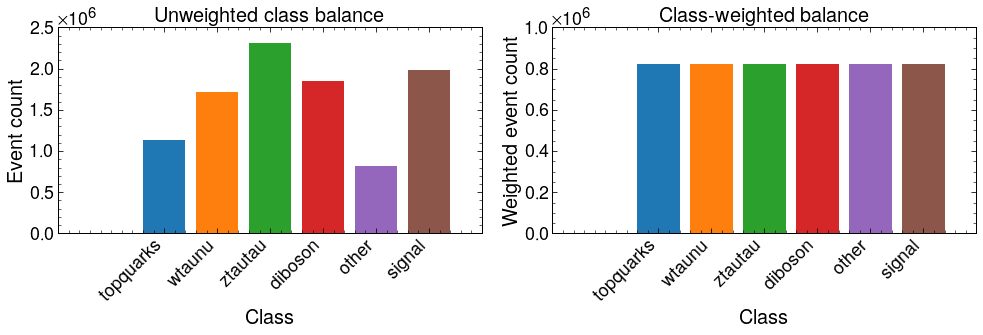

In [11]:
from src.eda.plots import plot_class_balance
from src.visualization.plots import save_figure

fig = plot_class_balance(df_mc, class_names=class_names)
save_figure(fig, plots_dir / "class_balance.png")
fig.show()

## Correlations

Plotting the Pearson correlation matrix for all training features. Highly correlated feature pairs (|r| > 0.9) are candidates for removal to reduce redundancy. Annotations are shown only for matrices with 30 or fewer features.

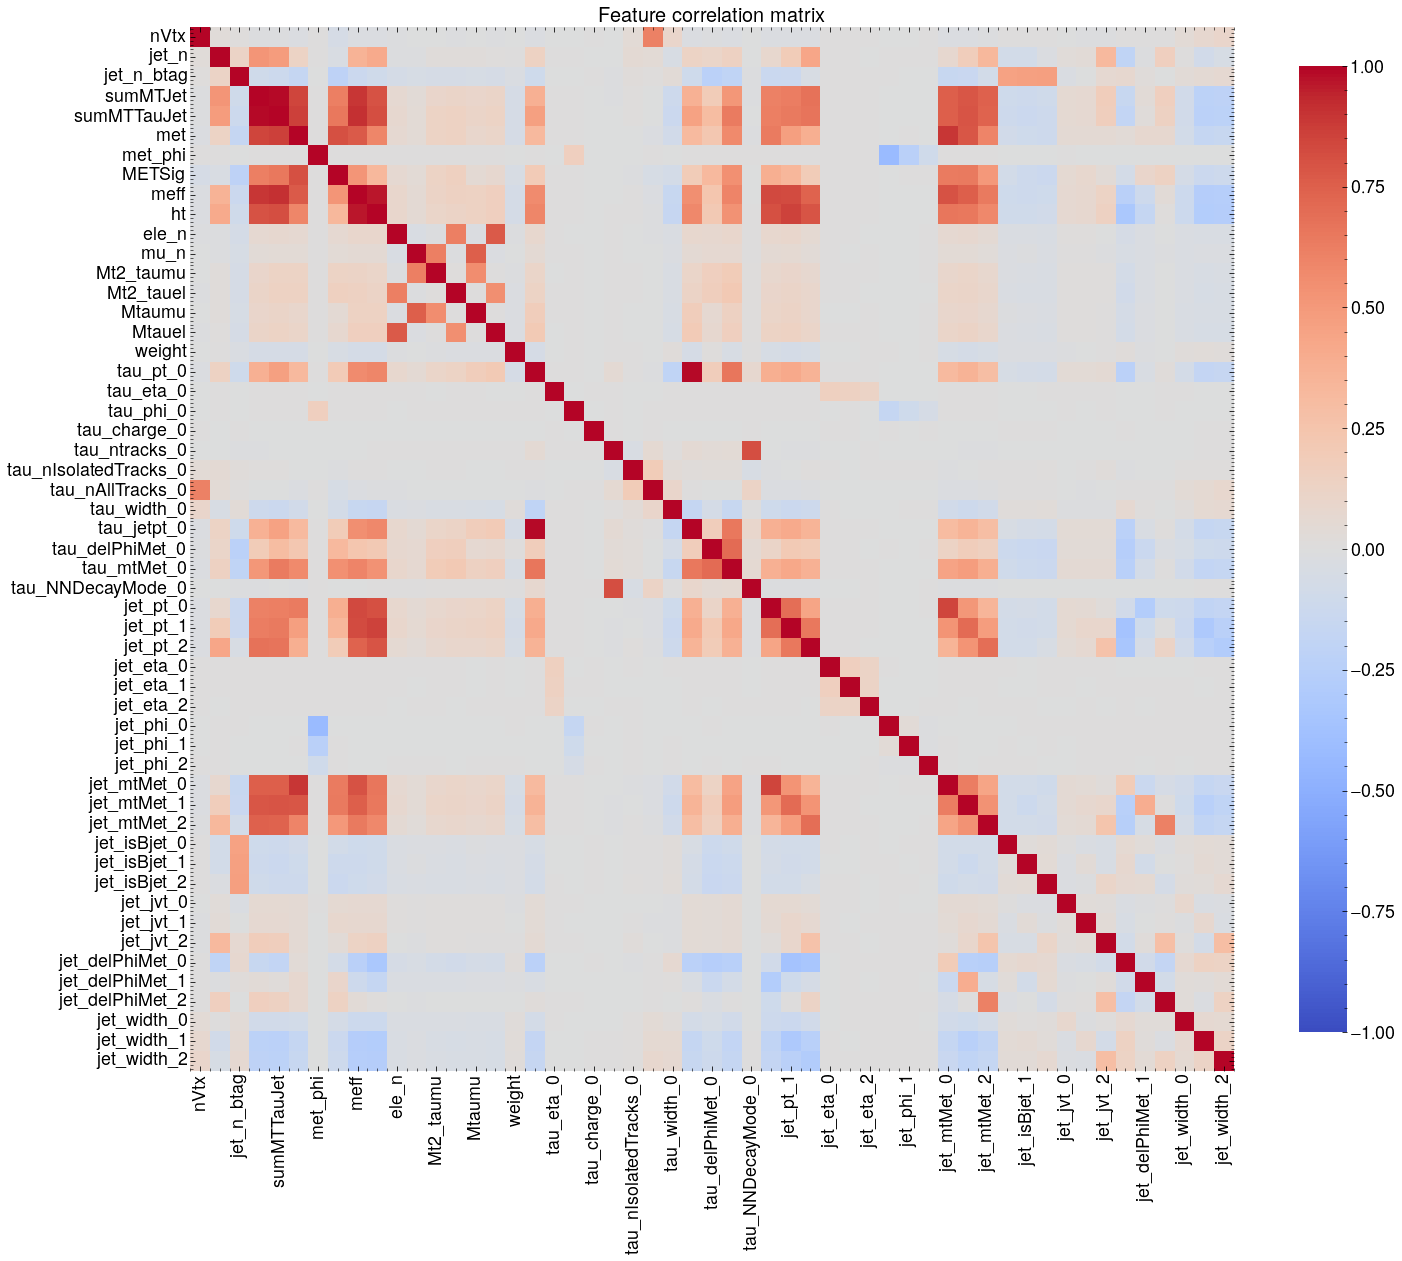

In [12]:
from src.eda.plots import plot_correlation_matrix
from src.visualization.plots import save_figure

fig = plot_correlation_matrix(df_mc)
save_figure(fig, plots_dir / "correlation_matrix.png")
fig.show()

## Feature Distributions

Plotting per-class normalized histograms for a selection of features. Modify `features` to inspect any subset of columns.

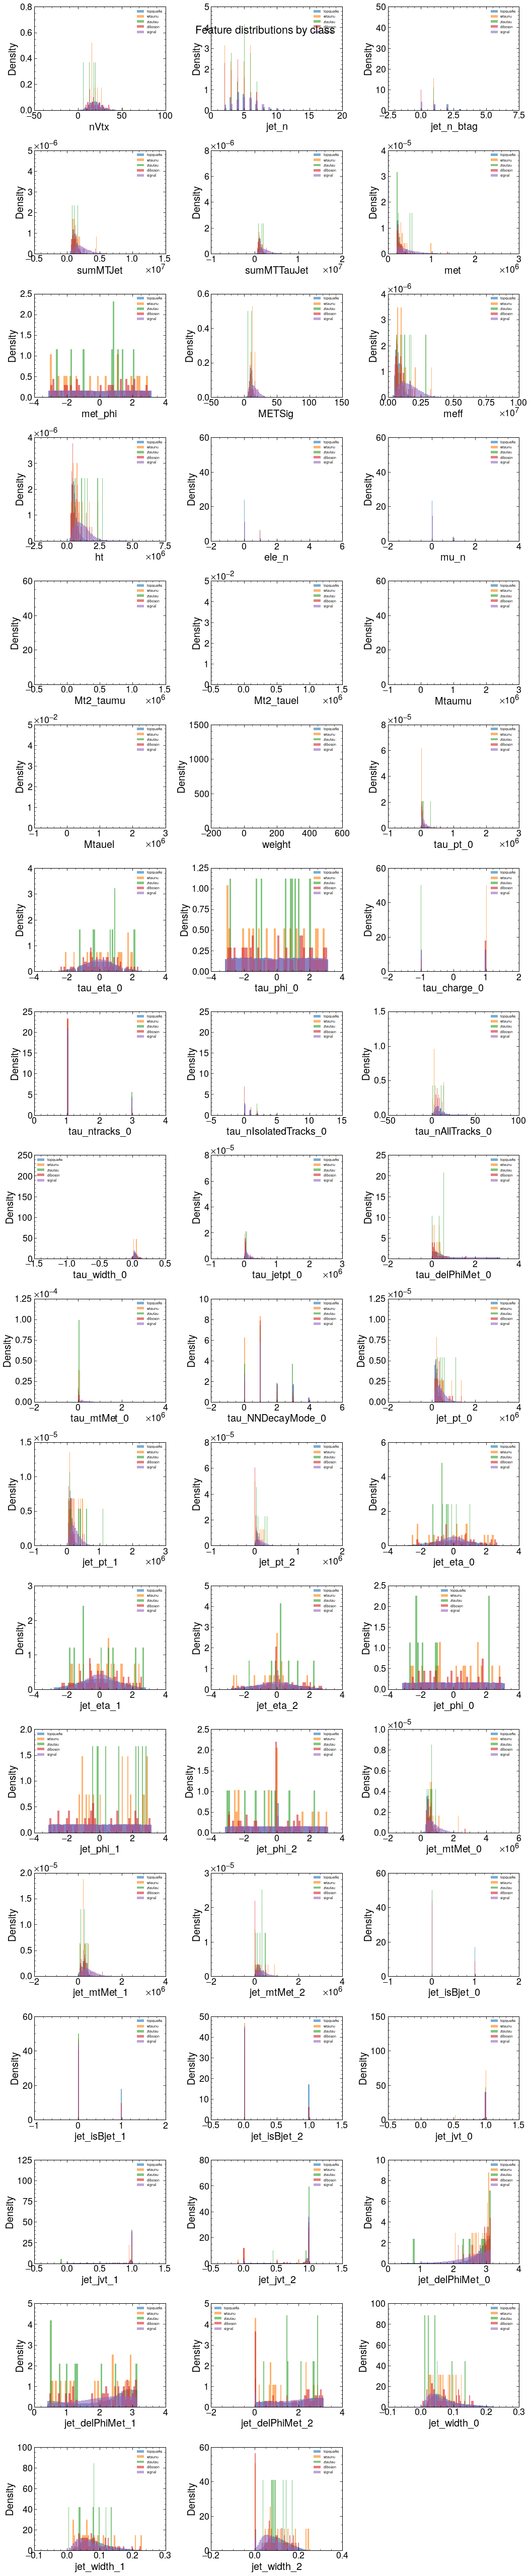

In [14]:
from src.eda.plots import plot_feature_distributions
from src.visualization.plots import save_figure

training_cols = [
    c for c in df_mc.select_dtypes(include="number").columns
    if c not in {"class", "class_weight", "tau_n"}
]
features = training_cols[::]

fig = plot_feature_distributions(df_mc, features=features, class_names=class_names)
save_figure(fig, plots_dir / "feature_distributions.png")
fig.show()